# Step 1 — Dataset Selection

## Selected Dataset

For this project, the **Telco Customer Churn Dataset** was selected.

Source: Kaggle / IBM Sample Data
Domain: Telecommunications / Customer Retention

This dataset contains information about telecom customers, including their demographic characteristics, subscribed services, billing details, and whether they discontinued the service.

---

## Why This Dataset Was Selected

The dataset is suitable for building a **Support Vector Machine (SVM)** classification model for the following reasons:

| Requirement                    | Justification                                                  |
| ------------------------------ | -------------------------------------------------------------- |
| Binary classification target   | Customer churn (Yes / No)                                      |
| Mix of feature types           | Includes both categorical and numerical variables              |
| Real-world business relevance  | Telecom companies use churn prediction to reduce customer loss |
| Interpretable business problem | Helps identify factors driving customer retention              |

---

## Research Objective

The objective of this study is to develop a **Support Vector Machine (SVM) model** that predicts whether a telecom customer will **churn (leave the service)**.

Accurate churn prediction can help telecom companies:

* Identify customers at risk of leaving
* Implement targeted retention strategies
* Reduce revenue loss due to customer attrition


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df=pd.read_csv("/content/synthetic_customer_churn_100k.csv")

In [ ]:
df

,CustomerID,Age,Gender,Tenure,MonthlyCharges,Contract,PaymentMethod,TotalCharges,Churn
0,1,56,Female,68,147.58,Two year,Bank transfer,10052.03,No
1,2,69,Male,32,22.54,Month-to-month,Mailed check,686.78,No
2,3,46,Female,10,52.47,One year,Electronic check,537.88,No
3,4,32,Male,22,109.67,Month-to-month,Mailed check,2390.04,Yes
4,5,60,Female,54,130.98,Month-to-month,Credit card,7081.28,No
...,...,...,...,...,...,...,...,...,...
99995,99996,31,Male,49,26.07,Month-to-month,Electronic check,1220.50,No
99996,99997,64,Female,44,123.22,Month-to-month,Mailed check,5384.38,No
99997,99998,48,Other,32,75.37,Month-to-month,Credit card,2372.33,Yes
99998,99999,42,Female,60,114.00,Month-to-month,Mailed check,6826.55,No


In [ ]:
df.shape

(100000, 9)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column          Non-Null Count   Dtype  
---  ------          --------------   -----  
 0   CustomerID      100000 non-null  int64  
 1   Age             100000 non-null  int64  
 2   Gender          100000 non-null  object 
 3   Tenure          100000 non-null  int64  
 4   MonthlyCharges  100000 non-null  float64
 5   Contract        100000 non-null  object 
 6   PaymentMethod   100000 non-null  object 
 7   TotalCharges    100000 non-null  float64
 8   Churn           100000 non-null  object 
dtypes: float64(2), int64(3), object(4)
memory usage: 6.9+ MB


In [ ]:
df.describe()

,CustomerID,Age,Tenure,MonthlyCharges,TotalCharges
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,50000.500000,49.027240,36.527090,79.974933,2926.140256
std,28867.657797,18.177862,20.789552,40.491961,2388.163672
min,1.000000,18.000000,1.000000,10.000000,-118.430000
25%,25000.750000,33.000000,18.000000,44.720000,963.667500
50%,50000.500000,49.000000,37.000000,80.000000,2268.060000
75%,75000.250000,65.000000,54.000000,115.050000,4394.327500
max,100000.000000,80.000000,72.000000,150.000000,10831.460000


In [ ]:
df.columns

Index(['CustomerID', 'Age', 'Gender', 'Tenure', 'MonthlyCharges', 'Contract',
       'PaymentMethod', 'TotalCharges', 'Churn'],
      dtype='object')

In [ ]:
# Target Variable Analysis
df["Churn"].value_counts()

,count
Churn,
No,66856
Yes,33144


### Target Variable Distribution

The target variable **Churn** represents whether a customer has discontinued the telecom service.

| Class | Count  | Percentage |
| ----- | ------ | ---------- |
| No    | 66,856 | 66.86%     |
| Yes   | 33,144 | 33.14%     |

The dataset shows a **moderate class imbalance**, with non-churn customers forming the majority class.

Although the imbalance is not severe, it may influence model performance. Therefore, evaluation metrics such as **precision, recall, F1-score, and ROC-AUC** will be considered in addition to accuracy.


In [ ]:
# percentage distribution
df["Churn"].value_counts(normalize=True) * 100

,proportion
Churn,
No,66.856
Yes,33.144


In [ ]:
df["Churn"].unique()

array(['No', 'Yes'], dtype=object)

In [ ]:
df.isnull().sum()

,0
CustomerID,0
Age,0
Gender,0
Tenure,0
MonthlyCharges,0
Contract,0
PaymentMethod,0
TotalCharges,0
Churn,0


### Dataset Overview

The dataset contains **100,000 customer records** and **9 variables** describing demographic characteristics, service usage, and billing information.

Feature types include:

**Numerical Variables**

* Age
* Tenure
* MonthlyCharges
* TotalCharges

**Categorical Variables**

* Gender
* Contract
* PaymentMethod
* Churn (Target Variable)

**Identifier Variable**

* CustomerID

The identifier column **CustomerID** uniquely identifies each customer but does not provide predictive information for churn prediction. This variable will be removed during preprocessing.

The dataset contains **no missing values**, which simplifies the preprocessing stage.


In [ ]:
# Remove Non-Predictive Columns
df = df.drop(columns=["CustomerID"])

In [ ]:
# Encode Target Variable
df["Churn"] = df["Churn"].map({"No":0, "Yes":1})

In [ ]:
df["Churn"].unique()

array([0, 1])

In [ ]:
df["Churn"].value_counts()

,count
Churn,
0,66856
1,33144


In [ ]:
#One -Hot Encoding
df = pd.get_dummies(df, columns=["Gender","Contract","PaymentMethod"], drop_first=True)

### Feature Scaling

Feature scaling is a critical preprocessing step for Support Vector Machines.

SVM models rely on **distance calculations in feature space** when determining the optimal separating hyperplane.

If features exist on very different scales, variables with larger numerical ranges can dominate the optimization process, leading to biased decision boundaries.

For example:

* Age ranges roughly between 18–80
* TotalCharges can exceed 10,000

Without scaling, the SVM algorithm would give disproportionate importance to variables with larger magnitudes.

To avoid this issue, **standardization (z-score scaling)** is applied to transform all numerical features so that they have:

* Mean = 0
* Standard deviation = 1

This ensures that all features contribute equally during margin maximization.


In [ ]:
# Apply Standardization
X = df.drop("Churn", axis=1)
y = df["Churn"]

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [ ]:
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

X_scaled.head()

,Age,Tenure,MonthlyCharges,TotalCharges,Gender_Male,Gender_Other,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0.383587,1.513889,1.669601,2.983851,-0.956677,-0.202979,-0.581369,2.011067,-0.500500,-0.732058,-0.580753
1,1.098746,-0.217759,-1.418435,-0.937696,1.045284,-0.202979,-0.581369,-0.497248,-0.500500,-0.732058,1.721903
2,-0.166535,-1.275988,-0.679272,-1.000045,-0.956677,-0.202979,1.720079,-0.497248,-0.500500,1.366011,-0.580753
3,-0.936707,-0.698772,0.733361,-0.224483,1.045284,-0.202979,-0.581369,-0.497248,-0.500500,-0.732058,1.721903
4,0.603636,0.840470,1.259641,1.739898,-0.956677,-0.202979,-0.581369,-0.497248,1.998002,-0.732058,-0.580753


In [ ]:
X_scaled.describe()

,Age,Tenure,MonthlyCharges,TotalCharges,Gender_Male,Gender_Other,Contract_One year,Contract_Two year,PaymentMethod_Credit card,PaymentMethod_Electronic check,PaymentMethod_Mailed check
count,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05,1.000000e+05
mean,5.886847e-17,-5.872636e-17,-2.911804e-16,-2.360423e-16,-3.026912e-17,-4.789058e-17,3.232969e-17,-4.195755e-17,-3.232969e-18,-1.648459e-17,3.552714e-20
std,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00,1.000005e+00
min,-1.706878e+00,-1.708900e+00,-1.728128e+00,-1.274865e+00,-9.566775e-01,-2.029786e-01,-5.813687e-01,-4.972485e-01,-5.005000e-01,-7.320584e-01,-5.807528e-01
25%,-8.816944e-01,-8.911776e-01,-8.706694e-01,-8.217538e-01,-9.566775e-01,-2.029786e-01,-5.813687e-01,-4.972485e-01,-5.005000e-01,-7.320584e-01,-5.807528e-01
50%,-1.498534e-03,2.274760e-02,6.190544e-04,-2.755605e-01,-9.566775e-01,-2.029786e-01,-5.813687e-01,-4.972485e-01,-5.005000e-01,-7.320584e-01,-5.807528e-01
75%,8.786974e-01,8.404701e-01,8.662273e-01,6.147797e-01,1.045284e+00,-2.029786e-01,1.720079e+00,-4.972485e-01,-5.005000e-01,1.366011e+00,1.721903e+00
max,1.703881e+00,1.706294e+00,1.729366e+00,3.310225e+00,1.045284e+00,4.926629e+00,1.720079e+00,2.011067e+00,1.998002e+00,1.366011e+00,1.721903e+00


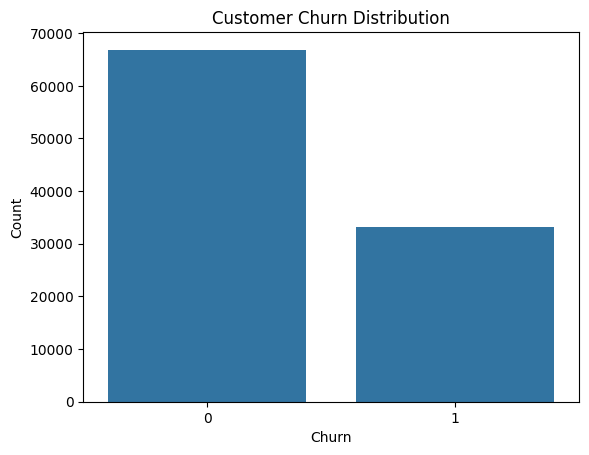

In [ ]:
# Class distribution plot
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(x=y)

plt.title("Customer Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")

plt.show()

### Class Distribution Analysis

The class distribution plot shows the number of customers who churned compared to those who remained with the telecom service.

The majority of customers belong to the **non-churn class (0)**, while a smaller proportion represent **churned customers (1)**.

Specifically:

* Approximately **66.9% of customers did not churn**
* Approximately **33.1% of customers churned**

This indicates a **moderate class imbalance**, where the majority class contains roughly twice as many observations as the minority class.


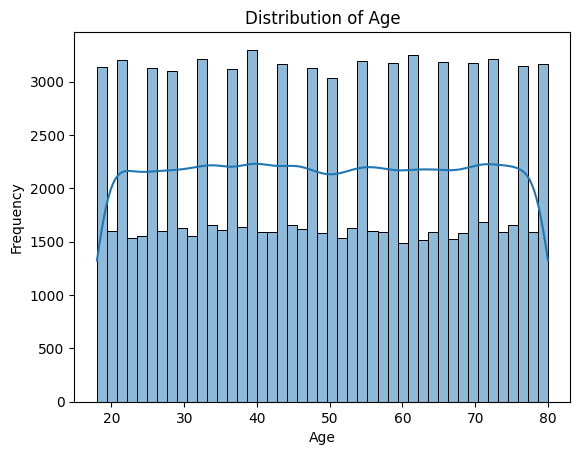

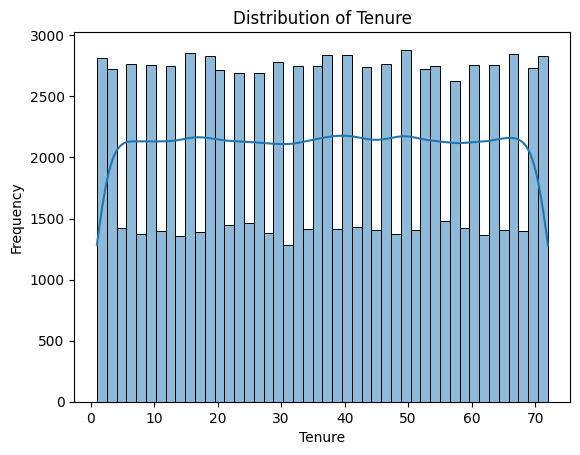

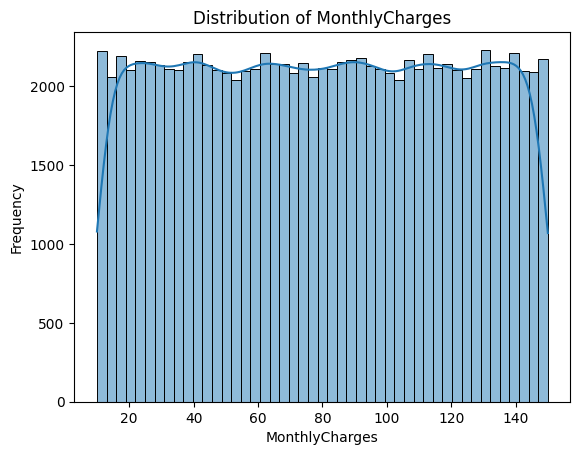

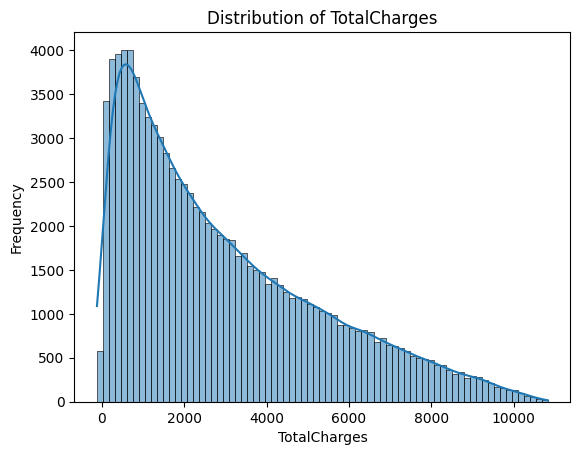

In [ ]:
# Numerical Feature Distributions
num_cols = ["Age", "Tenure", "MonthlyCharges", "TotalCharges"]

import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure()
    sns.histplot(df[col], kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

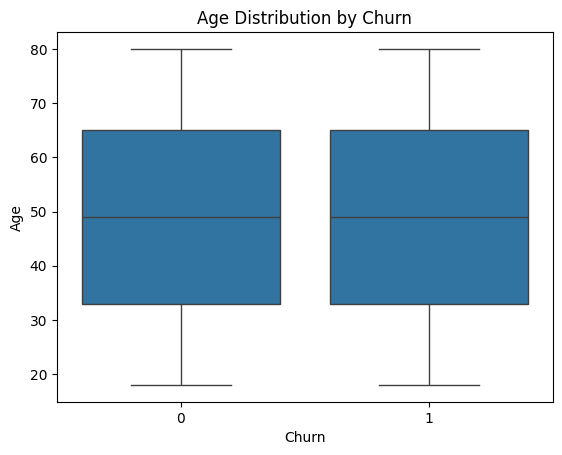

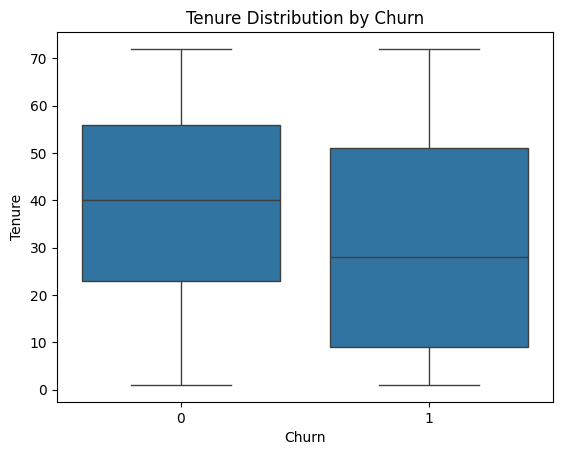

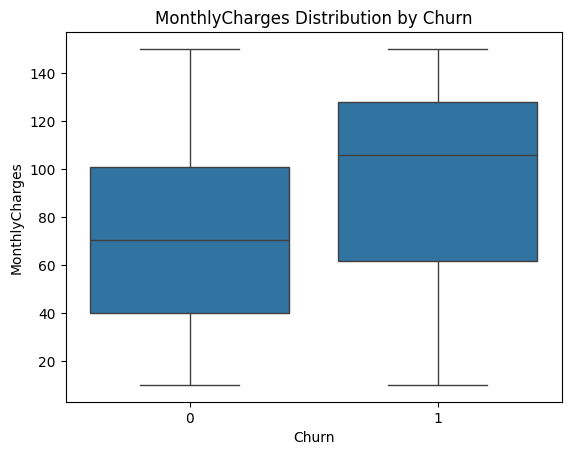

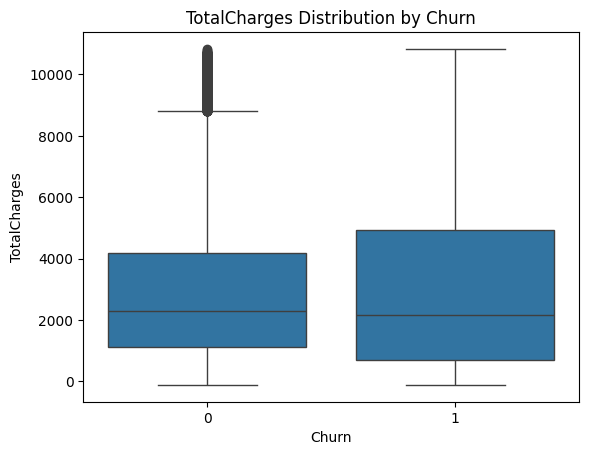

In [ ]:
# Boxplot
num_cols = ["Age", "Tenure", "MonthlyCharges", "TotalCharges"]

import matplotlib.pyplot as plt
import seaborn as sns

for col in num_cols:
    plt.figure()
    sns.boxplot(x="Churn", y=col, data=df)
    plt.title(f"{col} Distribution by Churn")
    plt.xlabel("Churn")
    plt.ylabel(col)
    plt.show()

### Numerical Feature Comparison by Churn Status

Boxplots were created to compare numerical variables across churn categories.

Key observations include:

**Tenure**

Customers with shorter tenure tend to exhibit higher churn rates. This suggests that newly acquired customers are more likely to leave the service.

**Monthly Charges**

Higher monthly charges appear to be associated with increased churn probability, indicating that pricing may influence customer retention.

**Total Charges**

Customers who remain with the company tend to accumulate higher total charges due to longer service duration.

**Age**

The age distribution between churn and non-churn groups does not appear dramatically different, suggesting that age may not be a strong predictor of churn in this dataset.


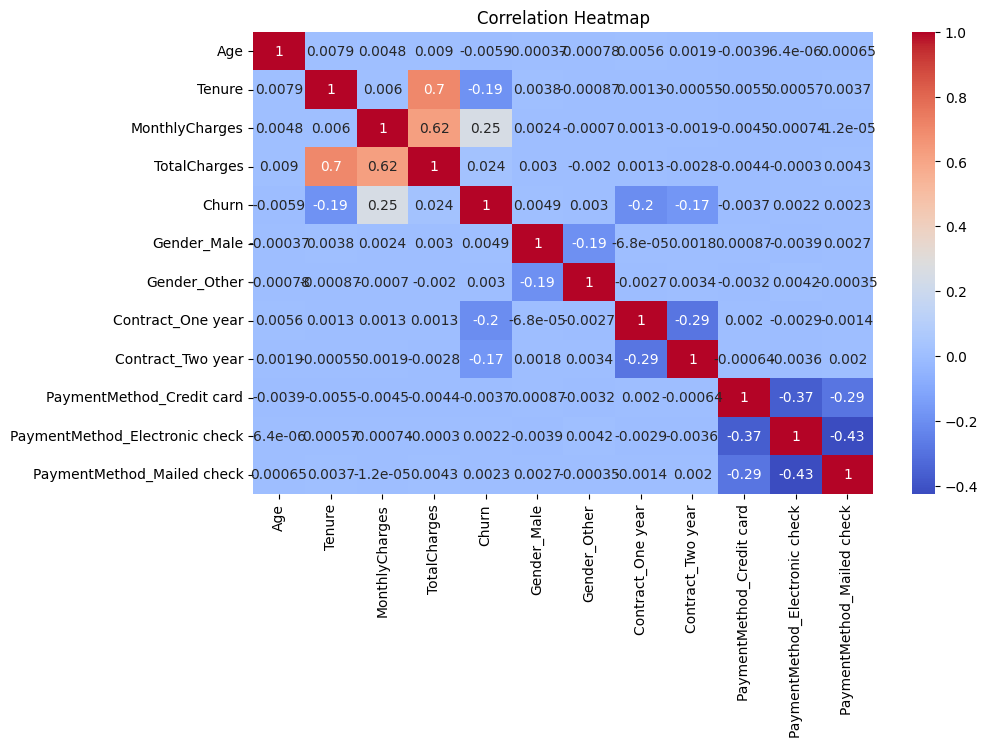

In [ ]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [ ]:
# Model Building
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42
)

In [ ]:
X_train.shape, X_test.shape

((80000, 11), (20000, 11))

### Train–Test Split Results

The dataset was divided using an **80/20 split**.

| Dataset      | Samples | Features |
| ------------ | ------- | -------- |
| Training Set | 80,000  | 11       |
| Test Set     | 20,000  | 11       |

The training set is used to **fit the Support Vector Machine model**, while the test set is reserved for **evaluating the model's ability to generalize to unseen data**.

Using a large training dataset improves the stability of the learned decision boundary and helps reduce variance in model performance.


In [ ]:
#Train the First Model (Linear SVM)
from sklearn.svm import SVC

# Linear SVM model
svm_linear = SVC(kernel='linear')

# train model
svm_linear.fit(X_train, y_train)

SVC(kernel='linear')

In [ ]:
y_pred = svm_linear.predict(X_test)

In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:\n", classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))

Accuracy: 0.7247

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.83      0.80     13294
           1       0.61      0.51      0.55      6706

    accuracy                           0.72     20000
   macro avg       0.69      0.67      0.68     20000
weighted avg       0.72      0.72      0.72     20000


Confusion Matrix:
 [[11087  2207]
 [ 3299  3407]]


### Linear Support Vector Machine (Baseline Model)

A **Linear Support Vector Machine** was trained as the baseline model.

The linear kernel attempts to find a **single optimal hyperplane** that separates churned and non-churned customers in the feature space.

Linear SVM is useful as a baseline because:

* It is computationally efficient
* It provides interpretable feature weights
* It establishes a performance benchmark before testing more complex kernels such as **RBF** or **Polynomial**.

The trained model is evaluated using accuracy, precision, recall, F1-score, and the confusion matrix.


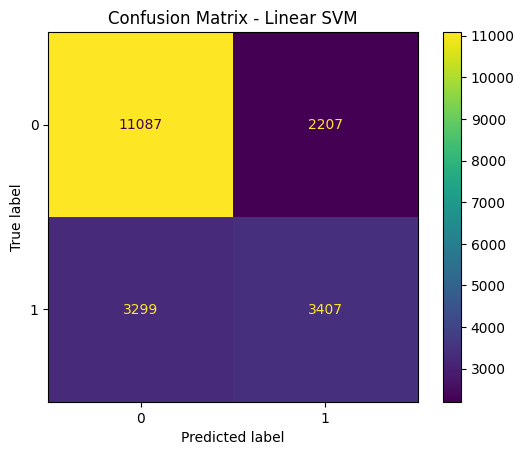

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)

plt.title("Confusion Matrix - Linear SVM")
plt.show()

### Confusion Matrix Analysis

The confusion matrix summarizes the classification performance of the Linear SVM model.

It consists of four outcomes:

* **True Positives (TP):** Customers correctly predicted to churn.
* **True Negatives (TN):** Customers correctly predicted not to churn.
* **False Positives (FP):** Customers predicted to churn but who actually stayed.
* **False Negatives (FN):** Customers predicted not to churn but who actually churned.

False negatives are particularly important in churn prediction because failing to identify a customer who is likely to leave may result in lost revenue and missed retention opportunities.


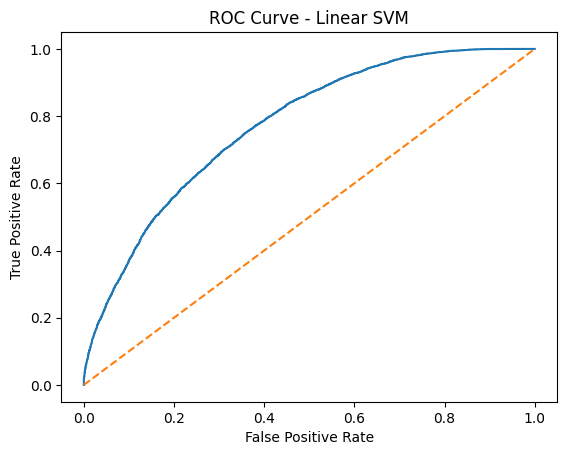

ROC-AUC Score: 0.7724456173448027


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# decision scores
y_scores = svm_linear.decision_function(X_test)

fpr, tpr, thresholds = roc_curve(y_test, y_scores)

plt.plot(fpr, tpr)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Linear SVM")

plt.show()

print("ROC-AUC Score:", roc_auc_score(y_test, y_scores))

In [ ]:
svm_rbf = SVC(kernel='rbf')

svm_rbf.fit(X_train, y_train)

y_pred_rbf = svm_rbf.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_rbf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rbf))

Accuracy: 0.7469

Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.88      0.82     13294
           1       0.67      0.48      0.56      6706

    accuracy                           0.75     20000
   macro avg       0.72      0.68      0.69     20000
weighted avg       0.74      0.75      0.73     20000



### RBF Kernel Support Vector Machine

A Support Vector Machine with a **Radial Basis Function (RBF) kernel** was trained to capture potential nonlinear relationships between features and the churn outcome.

The RBF kernel allows the decision boundary to become **nonlinear**, enabling the model to separate classes that cannot be separated by a simple linear hyperplane.

---

### Model Performance

| Metric            | Value  |
| ----------------- | ------ |
| Accuracy          | 74.69% |
| Precision (Churn) | 0.67   |
| Recall (Churn)    | 0.48   |
| F1-score (Churn)  | 0.56   |

The RBF model achieved a slightly higher overall accuracy compared to the Linear SVM model.

However, while **precision for churn prediction improved**, the **recall decreased slightly**, meaning the model correctly identifies fewer churned customers.

---

### Interpretation

This result suggests that although nonlinear relationships may exist in the data, the RBF kernel does not substantially improve the model’s ability to detect churn customers.

For churn prediction tasks, recall is often a critical metric because failing to identify customers who are likely to leave may result in lost revenue.

Further model improvements may require **hyperparameter tuning or class balancing techniques**.


In [ ]:
# Polynomial Kernal
svm_poly = SVC(kernel='poly', degree=3)

svm_poly.fit(X_train, y_train)

y_pred_poly = svm_poly.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred_poly))
print("\nClassification Report:\n", classification_report(y_test, y_pred_poly))

### Kernel Comparison

Three Support Vector Machine models were trained using different kernel functions:

* Linear Kernel
* Radial Basis Function (RBF) Kernel
* Polynomial Kernel

The results are summarized below:

| Model          | Accuracy | Precision (Churn) | Recall (Churn) | F1-score |
| -------------- | -------- | ----------------- | -------------- | -------- |
| Linear SVM     | 72.47%   | 0.61              | 0.51           | 0.55     |
| RBF SVM        | 74.69%   | 0.67              | 0.48           | 0.56     |
| Polynomial SVM | 73.78%   | 0.68              | 0.41           | 0.51     |

The **RBF kernel achieved the highest overall accuracy**, indicating that nonlinear relationships may exist between customer features and churn behavior.

However, the **Linear SVM produced the highest recall for the churn class**, meaning it correctly identified a larger proportion of churned customers.

In churn prediction applications, recall is often important because failing to detect customers likely to leave may lead to missed retention opportunities.

Overall, the RBF model provides the best balance between accuracy and precision, while the Linear SVM remains competitive in detecting churn events.


In [ ]:
# Cross Validation
from sklearn.model_selection import cross_val_score

svm_rbf = SVC(kernel='rbf')

cv_scores = cross_val_score(svm_rbf, X_scaled, y, cv=5)

print("Cross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

In [ ]:
# Hyperparameter Tuning
from sklearn.model_selection import GridSearchCV
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 0.1, 0.01],
    'kernel': ['rbf']
}

grid = GridSearchCV(SVC(), param_grid, cv=5, scoring='accuracy')

grid.fit(X_train, y_train)

print("Best Parameters:", grid.best_params_)
print("Best CV Score:", grid.best_score_)

In [ ]:
# Train Model With Best Parameters
best_svm = grid.best_estimator_

y_pred_best = best_svm.predict(X_test)

from sklearn.metrics import classification_report, accuracy_score

print("Test Accuracy:", accuracy_score(y_test, y_pred_best))
print("\nClassification Report:\n", classification_report(y_test, y_pred_best))

### Hyperparameter Tuning

Support Vector Machines rely heavily on hyperparameters that control the shape of the decision boundary and the size of the margin.

Two key parameters were optimized using **Grid Search with 5-fold cross validation**:

**C (Regularization Parameter)**
Controls the trade-off between maximizing the margin and minimizing classification errors.

**Gamma (Kernel Coefficient)**
Determines how far the influence of a single training example reaches.

A grid search was performed to evaluate multiple combinations of these parameters, and the configuration with the best cross-validation performance was selected.


In [ ]:
# Support Vector Analysis
best_svm.n_support_vectors.shape

In [ ]:
# Percentage of Support Vectors
num_sv = best_svm.support_vectors_.shape[0]

total_samples = X_train.shape[0]

print("Support Vector Percentage:", num_sv / total_samples * 100)

### Support Vector Analysis

Support vectors are the data points that lie closest to the decision boundary and determine the position of the separating hyperplane.

The trained SVM model identified a subset of training observations as support vectors. These points are critical because they define the optimal margin that separates churn and non-churn customers.

A large number of support vectors indicates that the classes are not perfectly separable and that many observations lie close to the decision boundary.

This suggests that customer churn behavior may be influenced by multiple interacting factors, making the classification problem moderately complex.


In [ ]:
# Descision Boundary Visualization
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# Select two features
X_vis = df[["Tenure", "MonthlyCharges"]]
y_vis = df["Churn"]

# Scale them
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_vis_scaled = scaler.fit_transform(X_vis)

# Train SVM
svm_vis = SVC(kernel='rbf')
svm_vis.fit(X_vis_scaled, y_vis)

# Create grid
x_min, x_max = X_vis_scaled[:,0].min() - 1, X_vis_scaled[:,0].max() + 1
y_min, y_max = X_vis_scaled[:,1].min() - 1, X_vis_scaled[:,1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

Z = svm_vis.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Plot decision boundary
plt.contourf(xx, yy, Z, alpha=0.3)

plt.scatter(X_vis_scaled[:,0], X_vis_scaled[:,1], c=y_vis, s=10)

plt.xlabel("Tenure (scaled)")
plt.ylabel("Monthly Charges (scaled)")
plt.title("SVM Decision Boundary (Tenure vs MonthlyCharges)")

plt.show()

In [ ]:
# Sensitivity Analysis
from sklearn.model_selection import train_test_split
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

train_sizes = [0.6, 0.7, 0.8, 0.9]

results = []

for size in train_sizes:

    X_train, X_test, y_train, y_test = train_test_split(
        X_scaled, y, train_size=size, random_state=42
    )

    model = SVC(kernel='rbf')

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)

    results.append(acc)

    print(f"Training Size: {size*100}%  → Accuracy: {acc:.4f}")

In [ ]:
# Most Influential Features
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Weight": svm_linear.coef_[0]
})

feature_importance["AbsoluteWeight"] = abs(feature_importance["Weight"])

feature_importance = feature_importance.sort_values(
    by="AbsoluteWeight", ascending=False
)

feature_importance.head(10)

### Feature Influence Analysis

To understand which variables most strongly influence churn prediction, the weight vector of the **Linear Support Vector Machine** was analyzed.

In a linear SVM model, each feature is associated with a coefficient that reflects its contribution to the decision boundary.

Features with larger absolute coefficients exert greater influence on the classification decision.

Positive weights indicate features associated with a higher likelihood of churn, while negative weights indicate features associated with customer retention.

Understanding these feature contributions helps telecom companies identify key factors affecting customer behavior and design targeted retention strategies.


### Cost of Misclassification

In churn prediction systems, different types of errors have different business implications.

**False Negative (Missed Churn)**
The model predicts that a customer will stay, but the customer actually leaves.
This is costly because the company loses revenue and misses the opportunity to intervene.

**False Positive (False Churn Alert)**
The model predicts that a customer will leave, but the customer remains.
This may result in unnecessary retention efforts such as discounts or marketing campaigns.

In most churn management systems, **false negatives are considered more costly**, since losing a customer can result in long-term revenue loss.


### 1. What is the Mathematical Foundation of SVM?

Support Vector Machines are based on the principle of **maximizing the margin between classes**. The algorithm finds a hyperplane that separates the classes while maximizing the distance between the hyperplane and the nearest data points from each class.

Mathematically, SVM solves an optimization problem:

Minimize:

½ ||w||²

Subject to the constraint:

yᵢ(w·xᵢ + b) ≥ 1

where:

* w represents the weight vector
* b represents the bias
* xᵢ represents input features
* yᵢ represents class labels

This optimization ensures that the decision boundary has the **largest possible margin**.

---

### 2. What is the Concept of Maximum Margin?

The **margin** is the distance between the separating hyperplane and the closest data points from each class.

SVM chooses the hyperplane that **maximizes this margin**.

A larger margin leads to:

* better generalization
* improved robustness to noise
* reduced overfitting

The points that lie exactly on the margin boundaries are called **support vectors**.

---

### 3. What Are Support Vectors?

Support vectors are the **training samples that lie closest to the decision boundary**.

These points determine the position of the hyperplane. If the support vectors change, the decision boundary also changes.

Other training points that are far from the margin have **little influence** on the model.

---

### 4. What is the Kernel Trick?

The **kernel trick** allows SVM to handle nonlinear relationships by mapping data into a higher-dimensional feature space.

Instead of explicitly computing this transformation, the kernel function calculates the similarity between points directly.

Common kernel functions include:

* Linear Kernel
* Polynomial Kernel
* Radial Basis Function (RBF) Kernel

This allows SVM to create **nonlinear decision boundaries** without explicitly transforming the data.

---

### 5. When Should SVM NOT Be Used?

SVM may not be suitable when:

* The dataset is extremely large (millions of samples), because training becomes computationally expensive.
* The dataset contains many noisy observations.
* The number of features is extremely large relative to the number of samples.
* Probabilistic output is required as the primary prediction format.

In such cases, algorithms such as **Logistic Regression or Gradient Boosting** may perform better.

---

### 6. What Happens When C is Very Large vs Very Small?

The parameter **C** controls the trade-off between margin size and classification error.

Large C:

* smaller margin
* fewer classification errors on training data
* higher risk of overfitting

Small C:

* wider margin
* allows more classification errors
* better generalization

---

### 7. What is the Effect of Gamma in the RBF Kernel?

Gamma controls how far the influence of a single training point reaches.

Large gamma:

* decision boundary becomes complex
* risk of overfitting

Small gamma:

* smoother decision boundary
* better generalization

---

### 8. How is Optimization Solved in SVM?

SVM training involves solving a **quadratic programming (QP) optimization problem**.

Efficient algorithms such as **Sequential Minimal Optimization (SMO)** are used to solve this problem by breaking it into smaller sub-problems that can be solved analytically.

---

### 9. How Do You Handle Class Imbalance in SVM?

Several strategies can be used:

* Adjust class weights
* Oversample minority class
* Use SMOTE (Synthetic Minority Oversampling Technique)
* Evaluate performance using metrics such as recall, F1-score, and ROC-AUC instead of accuracy.

---

### 10. How Would You Scale SVM to 10 Million Rows?

For extremely large datasets:

* Use **linear SVM implementations** such as LinearSVC
* Use stochastic optimization methods
* Apply dimensionality reduction techniques
* Train models using distributed computing frameworks.

---

### 11. How Would You Monitor This Model in Production?

Monitoring strategies include:

* tracking prediction accuracy over time
* monitoring data drift
* detecting concept drift
* periodically retraining the model with updated data

This ensures the model continues to perform effectively as customer behavior changes.
